In [2]:
!wsl curl -o dataset/produccion-agricola.json "https://www.datos.gov.co/resource/t2ca-uae5.json?\$limit=50000"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: Failed to open the file dataset/produccion-agricola.json: No such 

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) client returned ERROR on write of 15464 bytes


In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
#from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, FunctionTransformer, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from category_encoders.binary import BinaryEncoder
import phik
from phik import resources
from phik.binning import bin_data
from phik.decorators import *
from phik.report import  plot_correlation_matrix
import networkx as nx

In [ ]:
#Modelo semántico



In [115]:
df.sample(10).to_csv('data/sample.csv', index=False)

In [204]:
df = pd.read_json('data/produccion-agricola.json')
df.head()

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
0,Permanentes,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.0
1,Permanentes,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.0
2,Permanentes,Aguacate,Suroeste,1990,Montebello,17.0,12.0,78.0
3,Permanentes,Aguacate,Suroeste,1990,Santa Bárbara,150.0,140.0,980.0
4,Permanentes,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32721 entries, 0 to 32720
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tipo                32721 non-null  object 
 1   rubro               32721 non-null  object 
 2   subregion           32721 non-null  object 
 3   anio                32721 non-null  int64  
 4   municipio           32721 non-null  object 
 5   area_total          32721 non-null  float64
 6   area_produccion     32721 non-null  float64
 7   volumen_produccion  32721 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 2.0+ MB


In [ ]:
df.describe()

,anio,area_total,area_produccion,volumen_produccion
count,32721.000000,32680.000000,32287.000000,3.253500e+04
mean,2009.716787,435.615817,399.454878,3.145023e+03
std,8.894551,1223.919511,1145.616547,2.322381e+04
min,1990.000000,0.000000,-1.000000,-1.065810e-14
25%,2003.000000,19.700000,15.000000,5.580000e+01
50%,2011.000000,76.000000,65.000000,2.880000e+02
75%,2017.000000,315.000000,285.000000,1.276000e+03
max,2022.000000,36000.000000,36000.000000,1.039280e+06


In [ ]:
df.describe(include='O')

,tipo,rubro,subregion,municipio
count,32721,32721,32721,32721
unique,3,155,9,140
top,Permanentes,Café,Oriente,Medellín
freq,19753,2799,6802,732


In [26]:
df['rubro'].value_counts().mean()

211.1032258064516

In [23]:
(df['rubro'].value_counts()<20).sum()

56

In [38]:
df['rubro'].value_counts().loc[lambda x: x < 20].index

Index(['Calabacín', 'Naranja Jaffa', 'Chirimoya', 'Tabaco', 'Maíz Forrajero',
       'Caña Para Miel', 'Uva', 'Chontaduro', 'Arandano', 'Frutales',
       'Flores (Rosas)', 'Pitahaya', 'Cebollín', 'Flores',
       'Flores (Pompon - Crisantemo)', 'Guayaba Pera', 'Coco X Plátano',
       'Ñame Diamante', 'Achiote', 'Acelga', 'Algarrobo', 'Curcuma',
       'Ajonjoli', 'Caña Forrajera', 'Flores (Astromelias)', 'Sorgo',
       'Yuca Industrial', 'Plátano Burro', 'Tomillo', 'Vainilla', 'Corozo',
       'Moringa', 'Achin', 'Palmito', 'Anis', 'Coco x Plátano',
       'Coco x plátano', 'Café X Plátano', 'Banano Bocadillo', 'Jatropha',
       'Higuerillo', 'Pimienta', 'Aguacate Santa Ana', 'Guineo',
       'Achiote (Bija)', 'Mandarina Común', 'Haba', 'Perejil', 'Ruda',
       'Berenjena', 'Aguacate lorena', 'Estropajo', 'Papayuela',
       'Plátano X Borojó', 'ALGODÓN', 'Rábano'],
      dtype='object', name='rubro')

In [80]:
df['municipio'].value_counts().mean()

233.67142857142858

In [ ]:
df['municipio'].value_counts()

municipio
Medellín                732
Marinilla               575
Urrao                   549
El Carmen de Viboral    509
Támesis                 502
                       ... 
ARBOLETES                 7
ANGOSTURA                 7
ABRIAQUÍ                  5
San Andrés De C.          5
LA PINTADA                1
Name: count, Length: 140, dtype: int64

In [ ]:
#Imputar valores nulos
areas = df[['area_total', 'area_produccion', 'volumen_produccion']].columns
for i in df['tipo'].unique():
    for j in areas:
        media = df[df['tipo'] == i][j].mean()
        df.loc[df['tipo'] == i, j] = df.loc[df['tipo'] == i, j].fillna(media)

In [ ]:
df.groupby(['tipo'])['volumen_produccion'].mean()

tipo
Anuales         2257.987454
Permanentes     3861.514644
Transitorios    2016.794965
Name: volumen_produccion, dtype: float64

In [72]:
#Manejar duplicados
print(f'Total valores duplicados: {df.duplicated().sum()}')
print(f'\nVisualizar duplicados: \n{df[df.duplicated()]}')
df.drop_duplicates(inplace=True)
print(f'\nEliminar duplicados... \n\t Total valores duplicados: {df.duplicated().sum()}')

Total valores duplicados: 7

Visualizar duplicados: 
              tipo                rubro   subregion  anio  municipio  \
2268   Permanentes                 Caña       Norte  1995  Guadalupe   
2554   Permanentes              Naranja   Occidente  1995      Olaya   
2630   Permanentes    Plátano En Asocio       Norte  1995    Ituango   
5292   Permanentes                 Mora       Norte  1999    Yarumal   
5432   Permanentes    Plátano En Asocio    Nordeste  1999    Vegachí   
5435   Permanentes    Plátano En Asocio    Nordeste  1999       Yalí   
13067  Permanentes  Plátano Monocultivo  Bajo Cauca  2008   El Bagre   

       area_total  area_produccion  volumen_produccion  
2268        267.0            262.0              1257.6  
2554         11.8              7.3               149.2  
2630         85.7             80.7               201.8  
5292          5.5              3.0                15.0  
5432         69.5             67.5               405.0  
5435         85.0           

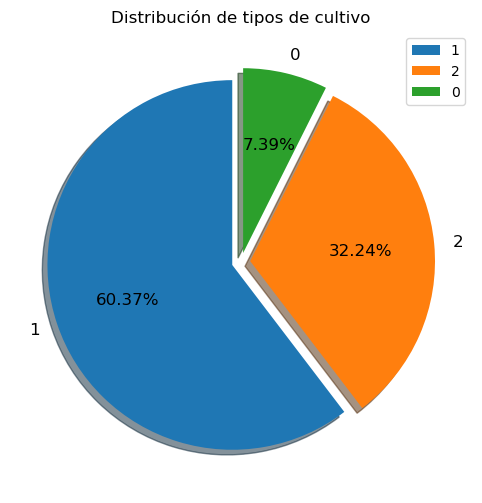

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df['tipo'].value_counts(), 
        labels=df['tipo'].unique(), 
        autopct='%0.2f%%', startangle=90, shadow=True, 
        explode=(0.05, 0.05, 0.05),      
        textprops={'fontsize': 12} )
plt.title('Distribución de tipos de cultivo')
plt.legend(df['tipo'].unique())
plt.show()

Text(0.5, 1.0, 'Top 10 Rubros')

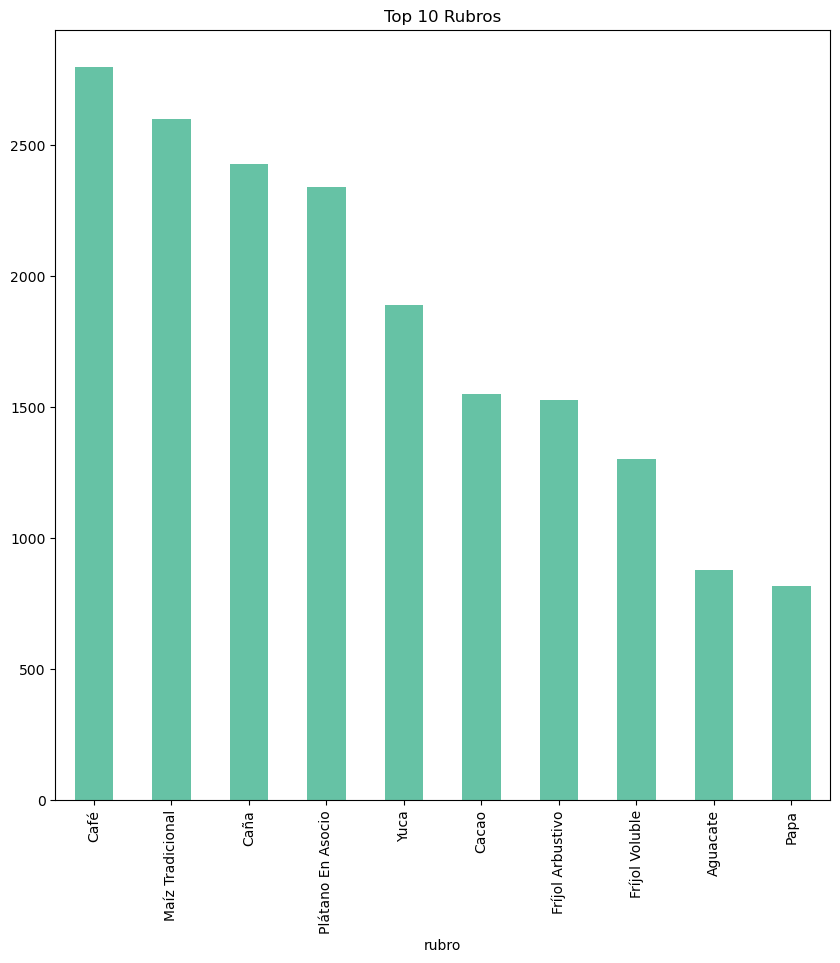

In [ ]:
plt.figure(figsize=(10, 10))
df['rubro'].value_counts().head(10).plot(kind='bar', colormap='Set2')
plt.title('Top 10 Rubros')

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

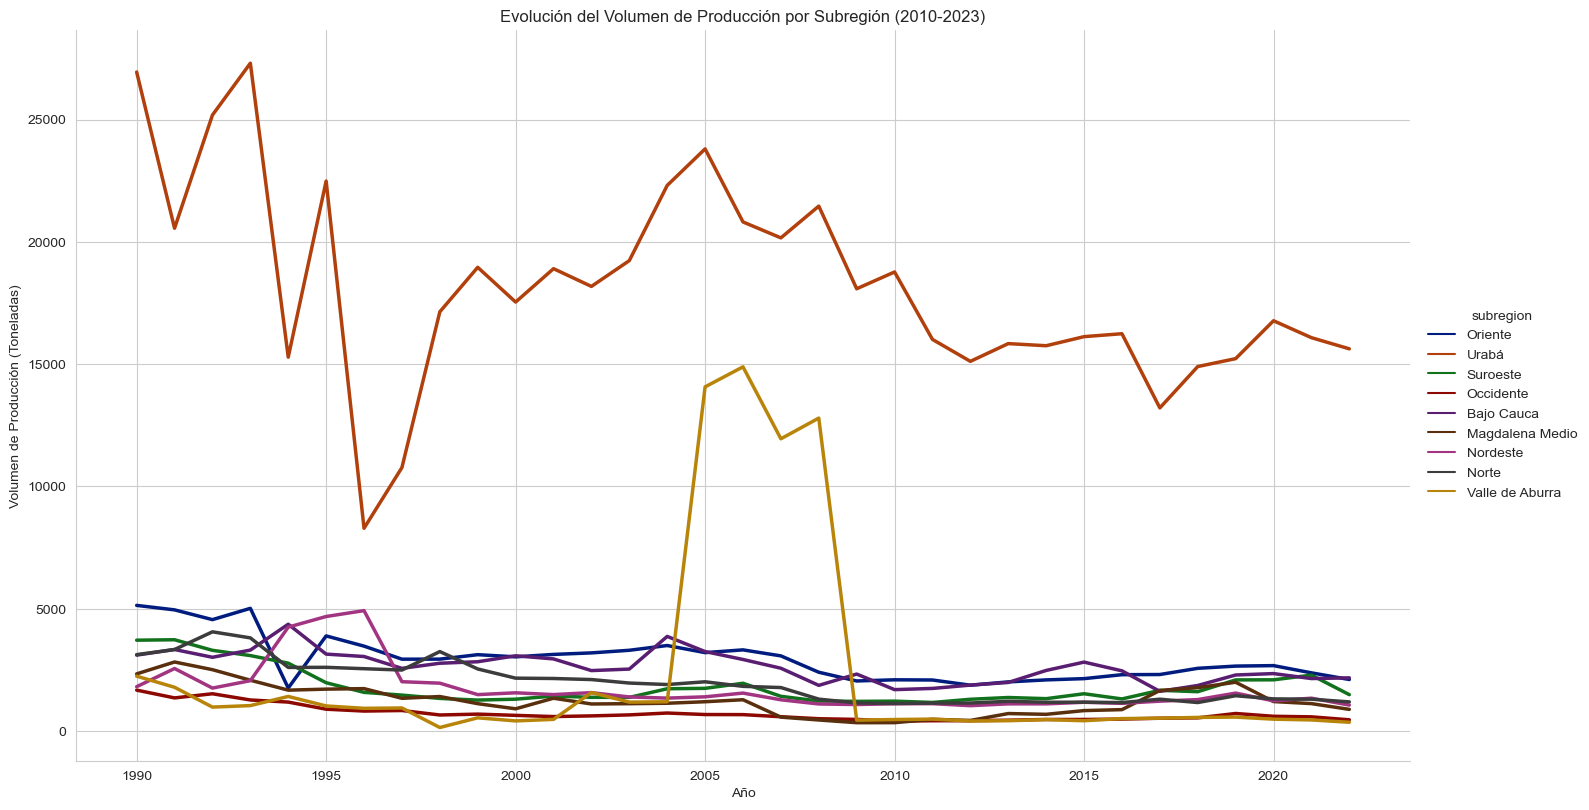

In [ ]:
grafico = sns.relplot(
    x='anio',
    y='volumen_produccion',
    data=df,
    hue='subregion',
    kind='line',
    height=8,  # Altura en pulgadas
    aspect=1.8,  # Relación ancho/alto
    palette='dark',  # Mejor esquema de colores
    linewidth=2.5,
    ci=None,  # Elimina intervalo de confianza si no es necesario
    legend='full'
)

# Personalización avanzada
grafico.set(
    title='Evolución del Volumen de Producción por Subregión (2010-2023)',
    xlabel='Año',
    ylabel='Volumen de Producción (Toneladas)'
)
plt.show()

In [ ]:
df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')]

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
0,Permanentes,Aguacate,Oriente,1990,Abejorral,45.0,23.0,138.000
1,Permanentes,Aguacate,Urabá,1990,Apartadó,29.0,27.0,405.000
4,Permanentes,Aguacate,Urabá,1990,Turbo,75.0,55.0,825.000
8,Transitorios,Arroz Tecnificado,Urabá,1990,Mutatá,750.0,355.0,1719.975
11,Transitorios,Arroz Tradicional,Urabá,1990,Arboletes,995.0,995.0,1194.000
...,...,...,...,...,...,...,...,...
32709,Transitorios,Zanahoria,Oriente,2022,Granada,6.0,6.0,270.000
32711,Transitorios,Zanahoria,Oriente,2022,La Unión,362.0,362.0,11228.000
32712,Transitorios,Zanahoria,Oriente,2022,Marinilla,190.0,188.0,5640.000
32715,Transitorios,Zanahoria,Oriente,2022,Sonsón,75.0,75.0,3525.000


In [ ]:
df['volumen_produccion']/df['area_produccion']

0         6.0
1        15.0
2         6.5
3         7.0
4        15.0
         ... 
32716     5.0
32717     2.0
32718     5.0
32719    13.5
32720     6.0
Length: 32721, dtype: float64

In [ ]:
df['area_produccion']/df['area_total']

0        0.511111
1        0.931034
2        0.705882
3        0.933333
4        0.733333
           ...   
32716    1.000000
32717    0.304348
32718    1.000000
32719    1.000000
32720    1.000000
Length: 32721, dtype: float64

In [ ]:
df.groupby(['anio','subregion'])['volumen_produccion'].mean().sort_values(ascending=False)

anio  subregion      
1993  Urabá              27809.181572
1990  Urabá              26947.686425
1992  Urabá              25188.573190
2005  Urabá              23804.757341
1995  Urabá              22489.673016
                             ...     
2010  Occidente            405.325543
2022  Valle de Aburra      359.404656
2010  Magdalena Medio      343.194231
2009  Magdalena Medio      342.151429
1998  Valle de Aburra      145.000000
Name: volumen_produccion, Length: 297, dtype: float64

(array([-50.,   0.,  50., 100., 150., 200., 250., 300., 350.]),
 [Text(-50.0, 0, '(2013, Magdalena Medio)'),
  Text(0.0, 0, '(1993, Urabá)'),
  Text(50.0, 0, '(1990, Suroeste)'),
  Text(100.0, 0, '(1990, Valle de Aburra)'),
  Text(150.0, 0, '(2010, Bajo Cauca)'),
  Text(200.0, 0, '(2013, Norte)'),
  Text(250.0, 0, '(2005, Occidente)'),
  Text(300.0, 0, ''),
  Text(350.0, 0, '')])

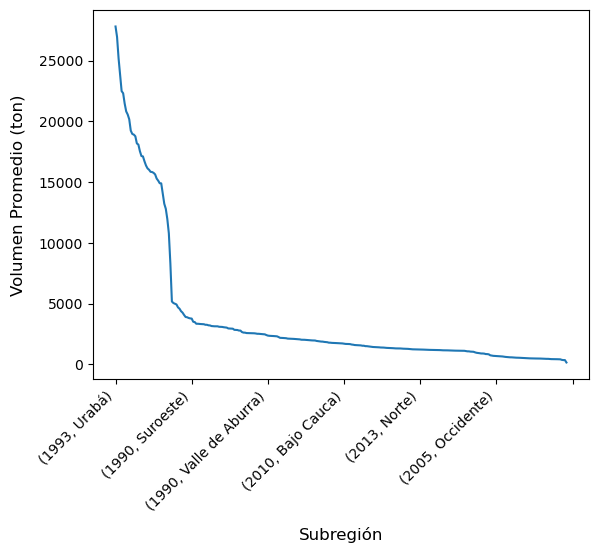

In [ ]:
df.groupby(['anio','subregion'])['volumen_produccion'].mean().sort_values(ascending=False).plot(kind='line')
plt.xlabel('Subregión', 
           fontsize=12, 
           labelpad=10)         # Espaciado de la etiqueta

plt.ylabel('Volumen Promedio (ton)', 
           fontsize=12, 
           labelpad=10)


plt.xticks(rotation=45, ha='right')  # Alineación a la derecha

<Axes: xlabel='subregion'>

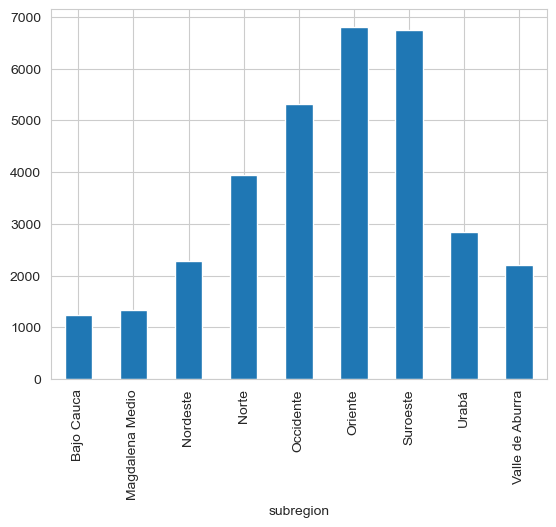

In [ ]:
df.groupby('subregion')['rubro'].count().plot(kind='bar')

<Axes: xlabel='rubro'>

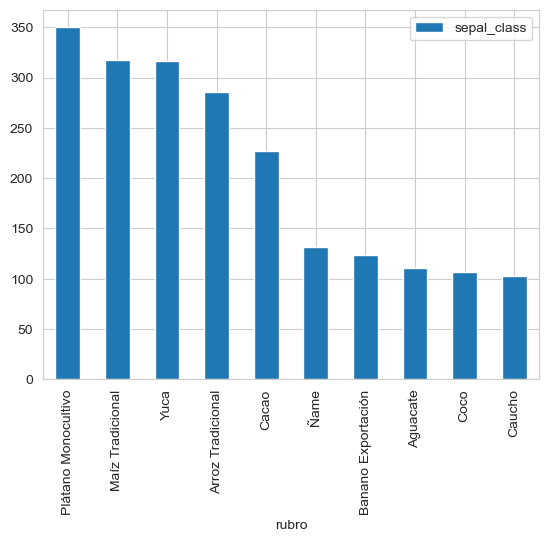

In [ ]:
df[df['subregion']=='Urabá'].groupby(['subregion', 'rubro']).size().reset_index(name='sepal_class').sort_values(by=['sepal_class'], ascending=False).head(10).plot(kind='bar', x='rubro', y='sepal_class')

In [ ]:
df[df['subregion']=='Oriente'].groupby(['subregion', 'rubro']).size().reset_index(name='sepal_class').sort_values(by=['sepal_class'], ascending=False).head(10)

,subregion,rubro,sepal_class
18,Oriente,Café,551
37,Oriente,Fríjol Voluble,496
60,Oriente,Papa,420
20,Oriente,Caña,417
68,Oriente,Plátano En Asocio,386
54,Oriente,Maíz Tradicional,358
55,Oriente,Mora,268
76,Oriente,Tomate De Árbol,265
79,Oriente,Yuca,232
17,Oriente,Cacao,206


In [ ]:
#de que tipo son los rubros mas comunes
df.groupby(['tipo', 'rubro']).size().reset_index(name='sepal_class').sort_values(by='sepal_class', ascending=False)

,tipo,rubro,sepal_class
29,1,Café,2799
145,2,Maíz Tradicional,2599
33,1,Caña,2429
101,1,Plátano En Asocio,2338
7,0,Yuca,1889
...,...,...,...
75,1,Mandarina Común,1
103,1,Plátano X Borojó,1
11,1,Achin,1
18,1,Aguacate lorena,1


c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping wi

<Axes: xlabel='volumen_produccion', ylabel='Count'>

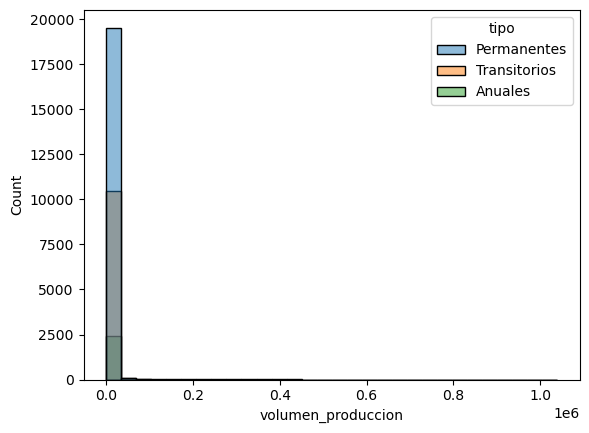

In [57]:
sns.histplot(data=df, hue='tipo', x='volumen_produccion', bins=30)

In [ ]:
grafico = sns.relplot(
    x='anio',
    y='volumen_produccion',
    data=df,
    hue='subregion',
    kind='line',
    height=8,  # Altura en pulgadas
    #aspect=1.8,  # Relación ancho/alto
    #palette=,  # Mejor esquema de colores
    linewidth=2.5,
    ci=None,  # Elimina intervalo de confianza si no es necesario
    legend='full'
)

# Personalización avanzada
grafico.set(
    title='Evolución del Volumen de Producción por Subregión (2010-2023)',
    xlabel='Año',
    ylabel='Volumen de Producción (Toneladas)'
)
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13928\3183495050.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barras = sns.barplot(data=df, y='volumen_produccion', x='subregion', hue='tipo',  # Altura en pulgadas


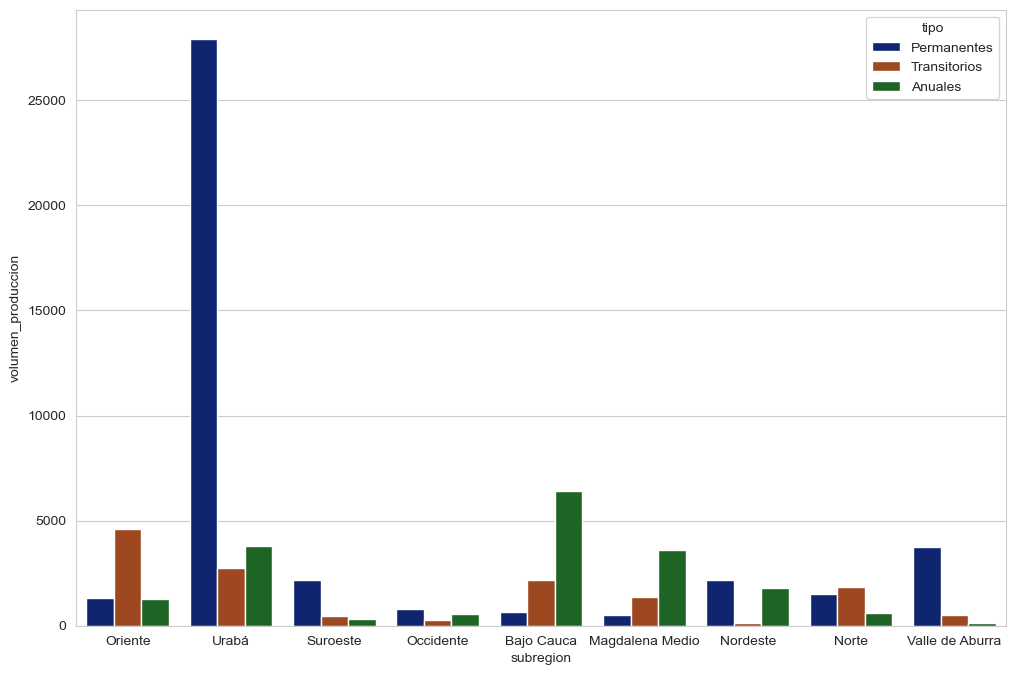

In [ ]:
plt.figure(figsize=(12, 8)) 
barras = sns.barplot(data=df, y='volumen_produccion', x='subregion', hue='tipo',  # Altura en pulgadas
    ci=None,
    palette='dark',  # Mejor esquema de colores
)


<Axes: xlabel='subregion', ylabel='area_total'>

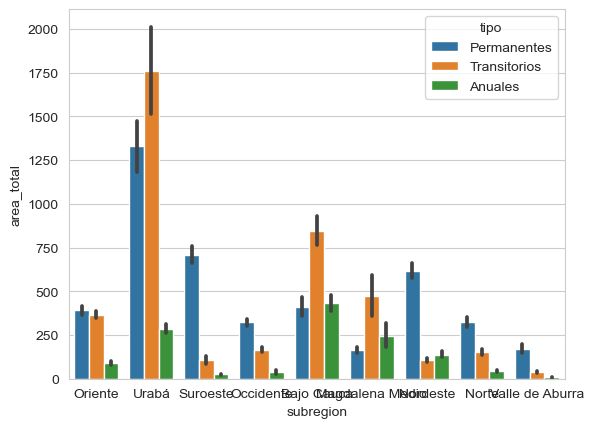

In [ ]:
sns.barplot(data=df, y='area_total', x='subregion', hue='tipo')

<Axes: xlabel='subregion', ylabel='area_total'>

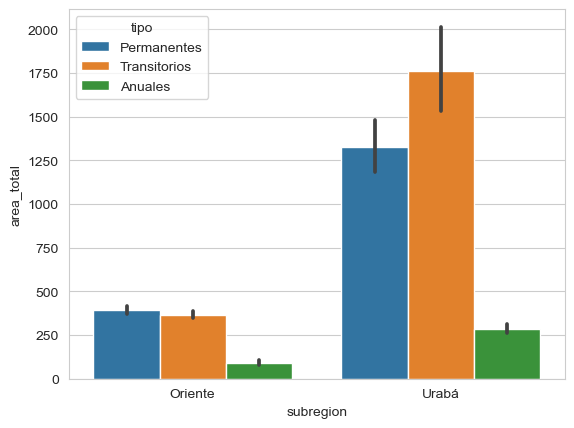

In [ ]:
sns.barplot(data=df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')], y='area_total', x='subregion', hue='tipo')

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='volumen_produccion', ylabel='Count'>

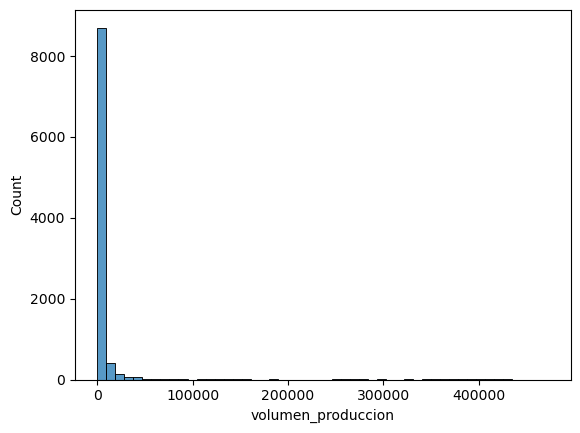

In [81]:
df_filtrado = df[(df['subregion']=='Oriente') | (df['subregion']=='Urabá')]
sns.histplot(x='volumen_produccion', data=df_filtrado, bins=50)

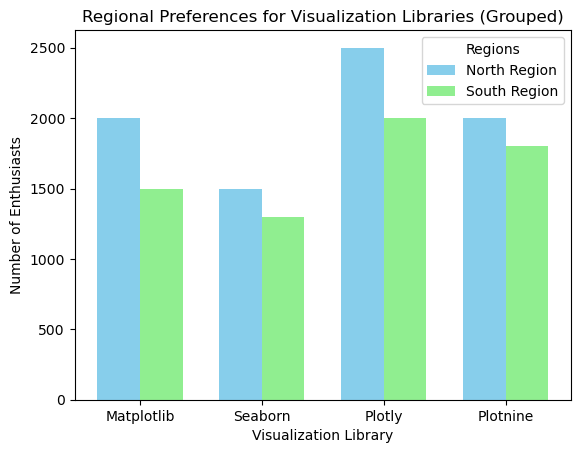

In [ ]:
# Define library names
library = ['Matplotlib', 'Seaborn', 'Plotly', 'Plotnine']

# Number of Enthusiasts for different regions
enthusiasts_north = [2000, 1500, 2500, 2000]
enthusiasts_south = [1500, 1300, 2000, 1800]
bar_width = 0.35
x = np.arange(len(library))

# Grouped Bar Plot
plt.bar(x - bar_width/2, enthusiasts_north, bar_width, label='North Region', color='skyblue')
plt.bar(x + bar_width/2, enthusiasts_south, bar_width, label='South Region', color='lightgreen')

# Adding labels and title
plt.xlabel('Visualization Library')
plt.ylabel('Number of Enthusiasts')
plt.title('Regional Preferences for Visualization Libraries (Grouped)')
plt.xticks(x, library)
plt.legend(title='Regions')
plt.show()

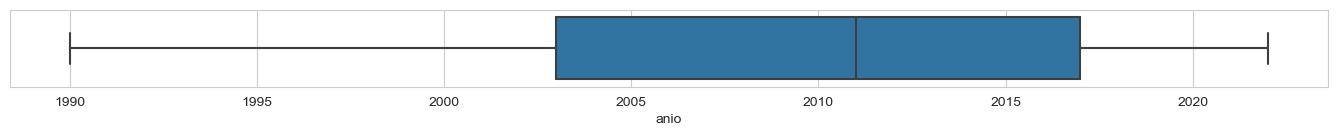

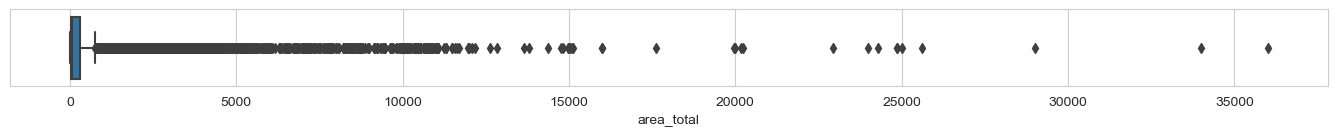

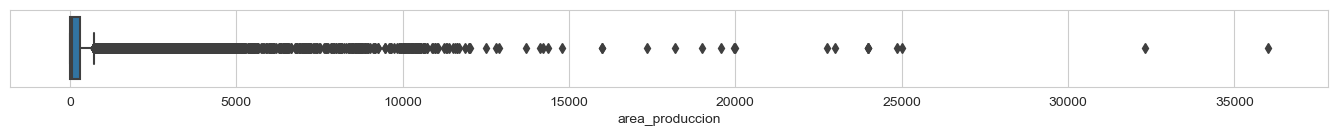

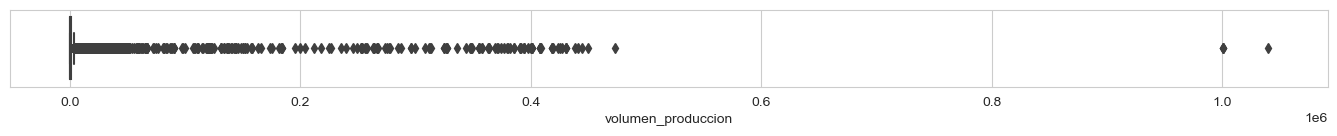

In [ ]:
cols = df.select_dtypes(include='number').columns
for i in cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=df[cols], x=i)

interval columns not set, guessing: ['anio', 'area_total', 'area_produccion', 'volumen_produccion']


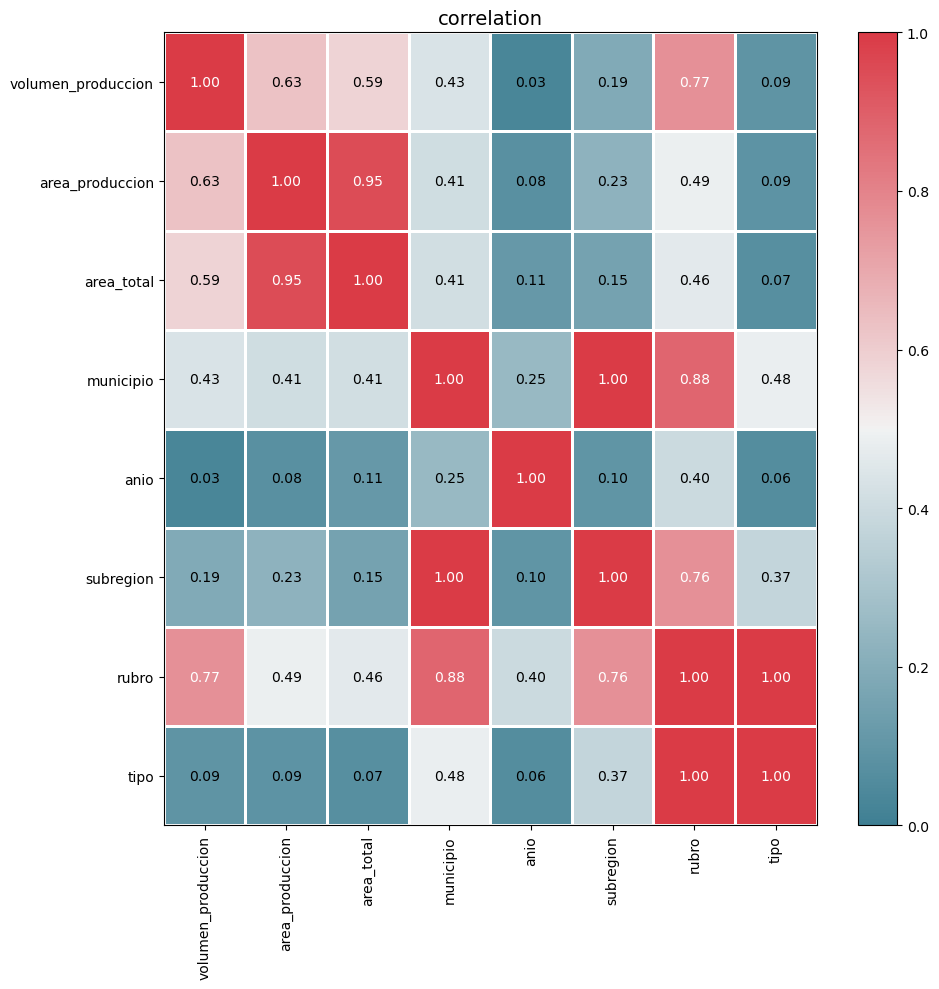

In [79]:
corre = df.phik_matrix()
cma = sns.diverging_palette(220, 10, as_cmap=True)

plot_correlation_matrix(corre.values, x_labels=corre.columns, y_labels=corre.index, vmin=0, vmax=1, color_map=cma, figsize=(10,10))

c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\USUARIO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping wi

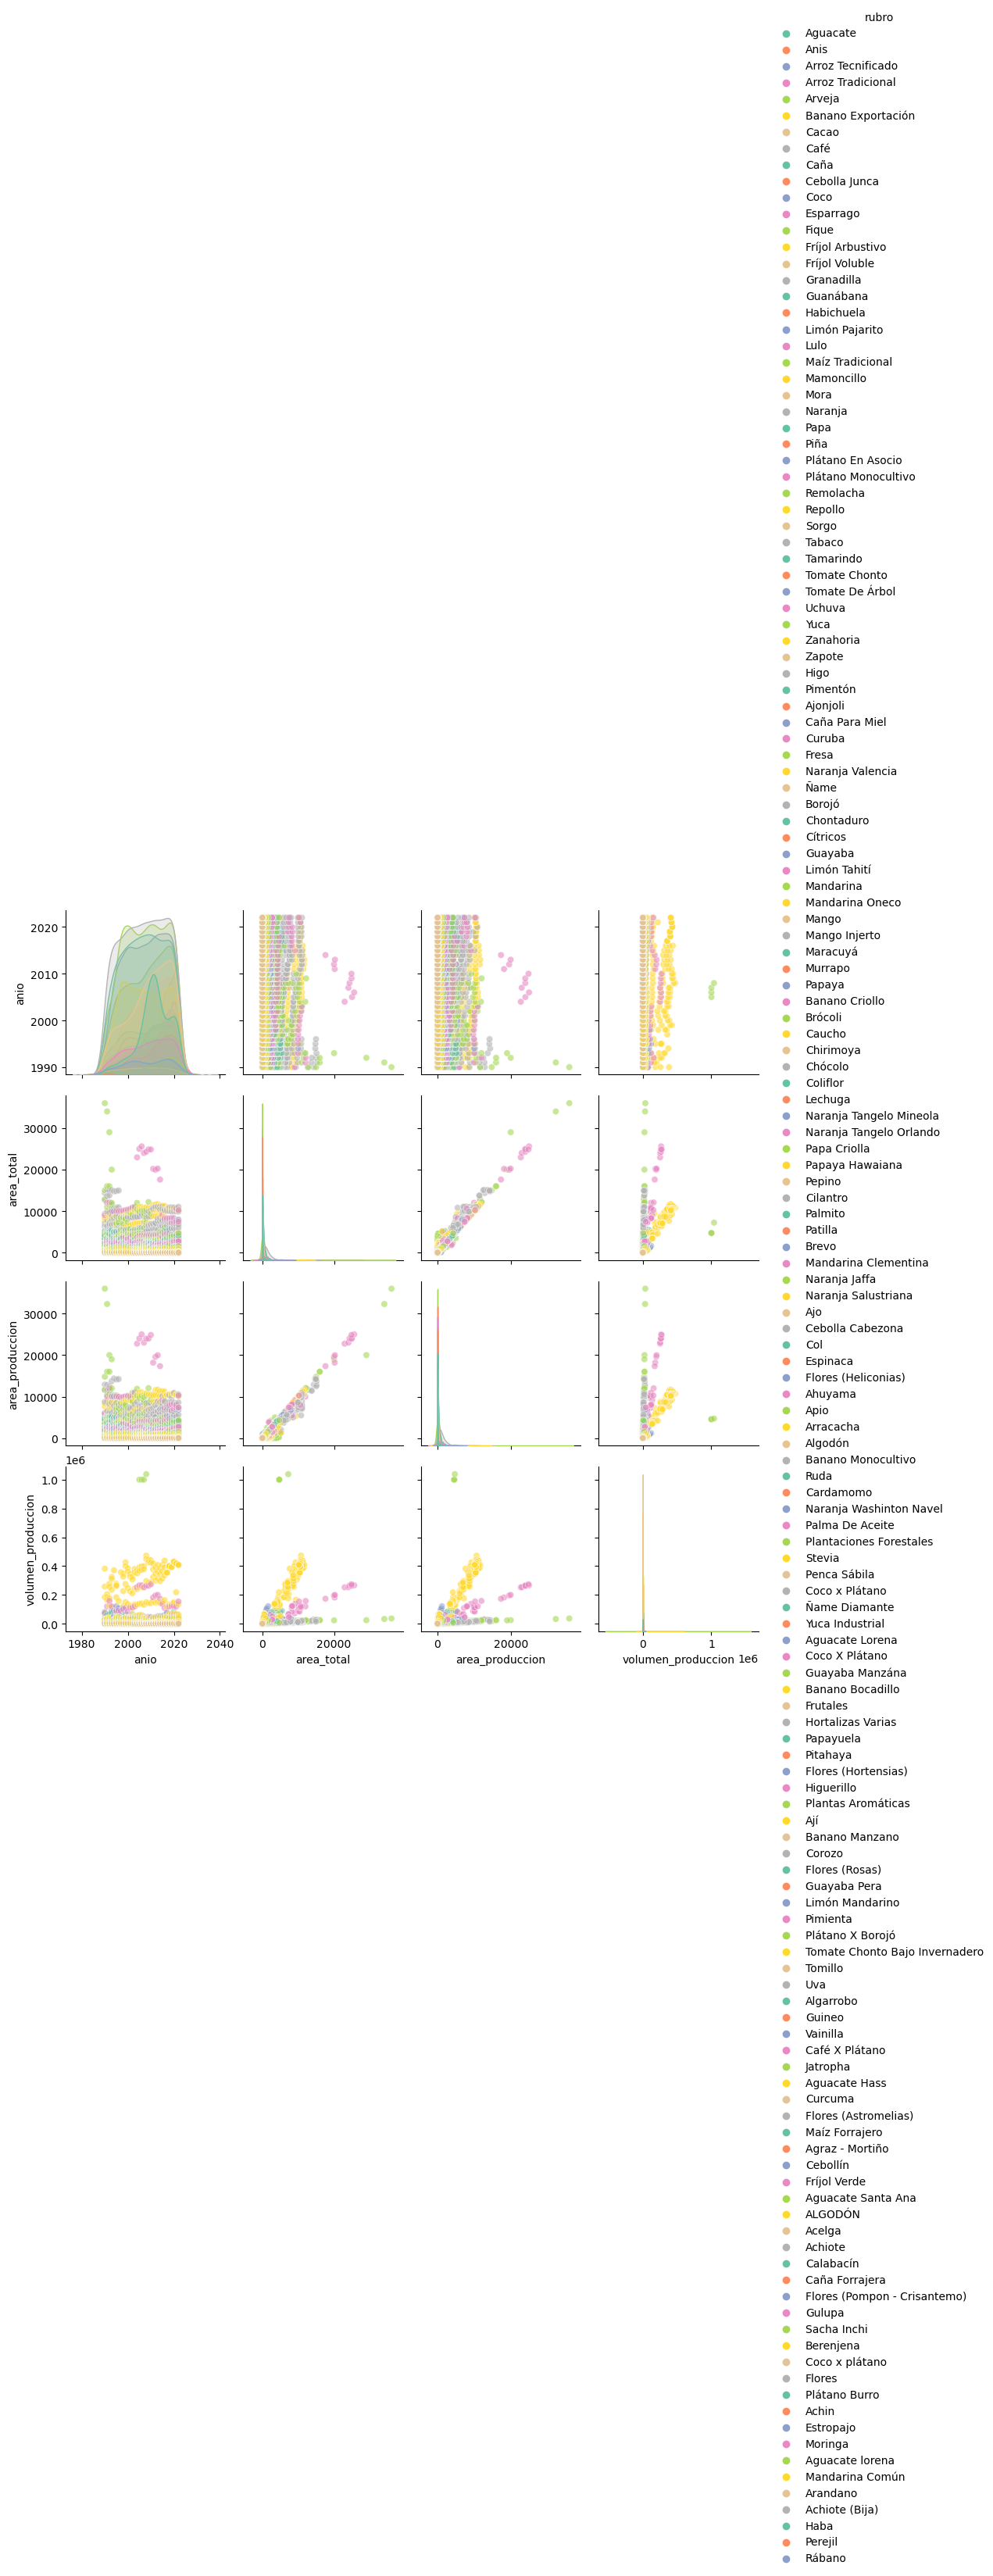

In [ ]:
grafico = sns.pairplot(data=df, hue='rubro', plot_kws={'alpha': 0.6})

In [ ]:
X=df.drop('rubro', axis=1)
y=df['rubro']
X.shape, y.shape

In [243]:
duplicates(df)
le = LabelEncoder()
le.fit(y)
Y_encoded = le.transform(y)
print(Y_encoded)

No se econtraron duplicados.
[ 1  1  1 ... 98 98 98]


In [244]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
X_train.shape, X_test.shape, X_val.shape

((26171, 7), (3271, 7), (3272, 7))

In [285]:
def duplicates(df):
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"Total duplicados: {duplicates}")
        #print(f"Visualizar duplicados:\n{df[df.duplicated()]}")
        df.drop_duplicates(inplace=True)
        print(f"Eliminar duplicados... Total duplicados: {X.duplicated().sum()}")
    else:
        print("No se econtraron duplicados.")
    return df

preprocess_duplicates = FunctionTransformer(duplicates)

In [217]:
def imputer(df):
    areas = df[['area_total', 'area_produccion', 'volumen_produccion']].columns
    for i in df['tipo'].unique():
        for j in areas:
            media = df[df['tipo'] == i][j].mean()
            df.loc[df['tipo'] == i, j] = df.loc[df['tipo'] == i, j].fillna(media)
    return df

preprocess_imputer = FunctionTransformer(imputer)

In [297]:
column_trans = ColumnTransformer(
    transformers=[
        ('cat_nominal', OneHotEncoder(), ['subregion']),
        ('cat_ordinal', OrdinalEncoder(), ['tipo']),
        ('cat_binary', BinaryEncoder(), ['municipio']),
        ('num', MinMaxScaler(), ['area_total', 'area_produccion', 'volumen_produccion', 'anio'])
    ],
    remainder='passthrough'  # Mantener las columnas no transformadas
)

In [294]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(), 
        'hyperparameters' : {
            'model__C': [0.1, 1, 10],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs'],
            'model__max_iter': [100, 200, 500],
            'model__multi_class': ['multinomial', 'ovr']
        }
    },
    'SVM': {
        'model': SVC(), 
        'hyperparameters' : {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf'],
            'model__gamma': ['scale', 'auto']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(), 
        'hyperparameters' : {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform', 'distance'],
            'model__algorithm': ['auto'],
            'model__metric': ['minkowski']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(), 
        'hyperparameters' : {
            'model__criterion': ['gini', 'entropy'],
            'model__splitter': ['best'],
            'model__max_depth': [None, 10, 20],
            'model__max_features': ['sqrt', 'log2', None]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(), 
        'hyperparameters' : {
            'model__n_estimators': [50, 100],
            'model__criterion': ['gini', 'entropy'],
            'model__max_depth': [None, 10, 20],
            'model__max_features': ['sqrt', 'log2']
        }
    },
    'GaussianNB': {
        'model': GaussianNB(), 
        'hyperparameters' : {
            'model__var_smoothing': [1e-9, 1e-8]
        }
    }
}

In [293]:
def create_pipeline(model):
    if isinstance(model, GaussianNB):
        # Simplificamos el pipeline para GaussianNB
        pipeline = Pipeline([
            ('impute_nulls', preprocess_imputer),
            ('Encoders', column_trans),
            ('model', model)
        ])
    else:
        pipeline = Pipeline([
            #('duplicates', preprocess_duplicates),
            ('impute_nulls', preprocess_imputer),
            ('Encoders', column_trans),
            ('model', model)
        ])
    return pipeline

In [235]:
# Combinar clases con menos de 5 muestras en "Otros"
for i in df.select_dtypes(include='O').columns:
    counts = df[i].value_counts()
    to_group = counts[counts < 20].index
    df[i] = df[i].apply(lambda x: 'Otros' if x in to_group else x)

In [240]:
df[df['municipio'] == 'Otros']

,tipo,rubro,subregion,anio,municipio,area_total,area_produccion,volumen_produccion
5691,Permanentes,Café,Valle de Aburra,2000,Otros,49.4,33.8,30.4
6183,Permanentes,Plátano En Asocio,Valle de Aburra,2000,Otros,49.0,49.0,110.3
6481,Permanentes,Café,Valle de Aburra,2001,Otros,49.4,15.8,14.2
6960,Permanentes,Plátano En Asocio,Valle de Aburra,2001,Otros,10.0,7.0,15.8
11416,Permanentes,Café,Valle de Aburra,2007,Otros,26.7,26.7,53.4
...,...,...,...,...,...,...,...,...
31593,Transitorios,Cilantro,Valle de Aburra,2022,Otros,2.5,1.8,3.6
31681,Transitorios,Fríjol Arbustivo,Valle de Aburra,2022,Otros,1.0,1.0,1.3
32517,Transitorios,Tomate Chonto,Valle de Aburra,2022,Otros,2.0,1.8,12.6
32592,Transitorios,Tomate Chonto Bajo Invernadero,Valle de Aburra,2022,Otros,2.0,2.0,120.0


In [261]:
import os
os.environ["JOBLIB_MULTIPROCESSING"] = "0"


In [ ]:
models_test = {
    'SVM': {
        'model': SVC(),
        'hyperparameters': {
            'model__C': [1],  # solo un parámetro para reducir combinaciones
            'model__kernel': ['linear']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'hyperparameters': {
            'model__n_neighbors': [3]
        }
    }
}

models_test2 = {
    'Logistic Regression': {
        'model': LogisticRegression(),
        'hyperparameters': {
            'model__C': [1],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs'],
            'model__max_iter': [200],
            'model__multi_class': ['ovr']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(),
        'hyperparameters': {
            'model__criterion': ['gini'],
            'model__splitter': ['best'],
            'model__max_depth': [10],
            'model__max_features': ['sqrt']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(),
        'hyperparameters': {
            'model__n_estimators': [100],
            'model__criterion': ['gini'],
            'model__max_depth': [10],
            'model__max_features': ['sqrt']
        }
    },
    'GaussianNB': {
        'model': GaussianNB(),
        'hyperparameters': {
            'model__var_smoothing': [1e-08]
        }
    }
}

In [301]:
for i, j in models.items():
    try:
        #print(f"\n🔍 Entrenando modelo: {i}")
        print(f"\n🔍 Entrenando modelo: {j['model']}")
        k = create_pipeline(j['model'])
        #print(f"Pipeline creado para {i}: {k}")
        print(f"GridSearchCV con parámetros: {j['hyperparameters']}")
        
        grid_s = GridSearchCV(
            estimator=k,
            param_grid=j['hyperparameters'],
            verbose=1,
            cv=2,
            error_score='raise'
        )
        
        print(f"Entrenando modelo {i} con GridSearchCV...")
        grid_s.fit(X_train, y_train)
        print(f'✅ {i} mejores parámetros: {grid_s.best_params_}\n')
        
    except Exception as e:
        import traceback
        print(f'❌ Error en modelo {i}: {e}\n')
        print(traceback.format_exc())  # Traza completa para ver el error




🔍 Entrenando modelo: LogisticRegression()
GridSearchCV con parámetros: {'model__C': [0.1, 1, 10], 'model__penalty': ['l2'], 'model__solver': ['lbfgs'], 'model__max_iter': [100, 200, 500], 'model__multi_class': ['multinomial', 'ovr']}
Entrenando modelo Logistic Regression con GridSearchCV...
Fitting 2 folds for each of 18 candidates, totalling 36 fits


c:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  "maxiter": max_iter,
c:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  "maxiter": max_it

✅ Logistic Regression mejores parámetros: {'model__C': 10, 'model__max_iter': 500, 'model__multi_class': 'multinomial', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


🔍 Entrenando modelo: SVC()
GridSearchCV con parámetros: {'model__C': [0.1, 1, 10], 'model__kernel': ['linear', 'rbf'], 'model__gamma': ['scale', 'auto']}
Entrenando modelo SVM con GridSearchCV...
Fitting 2 folds for each of 12 candidates, totalling 24 fits
✅ SVM mejores parámetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}


🔍 Entrenando modelo: KNeighborsClassifier()
GridSearchCV con parámetros: {'model__n_neighbors': [3, 5, 7], 'model__weights': ['uniform', 'distance'], 'model__algorithm': ['auto'], 'model__metric': ['minkowski']}
Entrenando modelo KNN con GridSearchCV...
Fitting 2 folds for each of 6 candidates, totalling 12 fits
✅ KNN mejores parámetros: {'model__algorithm': 'auto', 'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__weights': 'uniform'}


🔍 Entrenando modelo

c:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:86: FutureWarning: Function delayed is deprecated; The function `delayed` has been moved from `sklearn.utils.fixes` to `sklearn.utils.parallel`. This import path will be removed in 1.5.
  def _decorate_fun(self, fun):
c:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\utils\parallel.py:114: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  class _FuncWrapper:
c:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:86: FutureWarning: Function delayed is deprecated; The function `delayed` has been moved from `sklearn.utils.fixes` to `sklearn.utils.parallel`. This import path will be removed in 1.5.
  def _decorate_fun(self, fun):
c:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\utils\parallel.py:114: UserWarning: `sklearn.utils.paral

✅ Random Forest mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': None, 'model__max_features': 'log2', 'model__n_estimators': 100}


🔍 Entrenando modelo: GaussianNB()
GridSearchCV con parámetros: {'model__var_smoothing': [1e-09, 1e-08]}
Entrenando modelo GaussianNB con GridSearchCV...
Fitting 2 folds for each of 2 candidates, totalling 4 fits
✅ GaussianNB mejores parámetros: {'model__var_smoothing': 1e-08}



In [ ]:
#✅ Logistic Regression mejores parámetros: {'model__C': 10, 'model__max_iter': 500, 'model__multi_class': 'multinomial', 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
#✅ SVM mejores parámetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}       se demora mucho
#✅ KNN mejores parámetros: {'model__algorithm': 'auto', 'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__weights': 'uniform'}
#✅ Decision Tree mejores parámetros: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_features': None, 'model__splitter': 'best'}
#✅ Random Forest mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': None, 'model__max_features': 'log2', 'model__n_estimators': 100}      se demora mucho
#✅ GaussianNB mejores parámetros: {'model__var_smoothing': 1e-08}

In [272]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="category_encoders")


In [152]:
Hyperparameters = [
    (regressor, LogisticRegression_Hyperparameters),
    (svm, SVM_Hyperparameters),
    (knn, KNN_Hyperparameters),
    (tree, DecisionTree_Hyperparameters),
    (forest, RandomForest_Hyperparameters),
    (gaussian, GaussianNB_Hyperparameters)]

NameError: name 'regressor' is not defined

In [ ]:
for i in Hyperparameters:
    grid_s = GridSearchCV(estimator=i[0], param_grid=i[1])
    grid_s.fit(X_train, y_train)

    print(f'Mejores parametros: {grid_s.best_params_}')

In [ ]:
#para hacer FunctionTransformer nos basamos en
#https://www.youtube.com/watch?v=xIqX1dqcNbY

#para hacer ColumnTransformer nos basamos en
#https://www.youtube.com/watch?v=irHhDMbw3xo

#para hacer binary encoder nos basamos en
#https://www.youtube.com/watch?v=NuZuJL6TqI0

In [ ]:
#Conclusiones